## Лабораторная работа №7. Решение краевой задачи.

### Метод стрельбы
Рассматриваем уравнение n-го порядка
$$y^{(n)} = f(x, y, y', ... , y^{(n-1)})$$

С краевыми условиями 
$$\mathbf{g}(\mathbf{y}(a),\mathbf{y}(b)) = \mathbf{0}$$



Сведение к системе (если не система изначально дана):
$$y'_1 = y_2 \\ y'_2 = y_3 \\ ... \\ y'_{n-1} = y_n \\ y'_n = f(x, y_1, y_2, ... , y_n)$$

То есть к задаче ОДУ
$$\frac{d\mathbf{y}}{dx} = \mathbf{f}(x, \mathbf{y}), x \in [a, b], \mathbf{y} \in \mathbb{R}^{n}$$
С краевыми условиями 
$$\mathbf{g}(\mathbf{y}(a),\mathbf{y}(b)) = \mathbf{0}$$



Подбираем параметр $\alpha = (\alpha_{1}, ... , \alpha_{n})$. $y(0) = \alpha_{0}$. Решаем задачу Коши.
После выстрела попадание в $\theta(l)$, невязка краевых условий: $\psi(\alpha) = y(b, \alpha) - \theta(l)$. Итерационный процесс: 
$$\alpha_{k+1} = \alpha_{k} - \frac{\psi(\alpha)}{\psi_{\alpha}'(\alpha)} $$
Получается, что необходимо решение двух задач Коши для нахождения $\psi_{\alpha}'$. Сведём это к решению одной задачи Коши:
$$\frac{dy}{dx} = f(x, y) \Rightarrow \frac{dy'}{d\alpha} = \frac{df}{dy}\frac{dy}{d\alpha} \Rightarrow \frac{d}{dx}\frac{dy}{d\alpha} = \frac{df}{dy}\frac{dy}{d\alpha}$$
*При условии, что $y(x, \alpha) \in C^2(\mathbb{R}^{m + 1})$.*


Замена $v = \frac{dy}{d\alpha}$ - Якобиан (nxn) ($\alpha$ - вектор). Получается следующая система:
$$(v_{x}')_{n \times n} = (\frac{df}{dy})_{n \times n} (v)_{n \times n}$$
Эту систему можно разложить в n систем по n уравнений. Решая задачу Коши 

$$y' = f(x, y) \\ v_{1x}' = \frac{df}{dy} v_{1} \\ v_{2x}' = \frac{df}{dy} v_{2} \\ ... \\ v_{nx}' = \frac{df}{dy} v_{n}$$
С начальными условиями 
$$y(0) = \alpha \\ v(0, \alpha) = I$$

находим $y(x)$ и $v(x, \alpha)$. Замечаем, что 
$$(\psi_{\alpha}')_{n \times n} = \frac{dg}{dy(a)} \frac{dy(a)}{d\alpha} + \frac{dg}{dy(b)} \frac{d y(b)}{d\alpha}$$

или

$$(\psi_{\alpha}')_{n \times n} = (\frac{dg}{dy(a)})_{n \times n} (v(a))_{n \times n} + (\frac{dg}{dy(b)})_{n \times n} (v(b))_{n \times n} $$

Тогда, решая линейную систему уравнений 
$$(\psi_{\alpha}')_{n \times n} (d \alpha)_{n \times 1} = - (\psi)_{n \times 1}$$
Находим изменение $\alpha$:
$$\alpha_{k + 1} = \alpha_{k} + d\alpha_{k}$$

Таким итерационным процессом решение сходится к решению краевой задачи.

Решение считаем найденным, когда выполняется учловие $|\psi(\alpha_{k+1})| < \varepsilon$.

### Метод квазилинеализации

In [31]:
from comp_math.bvp.model.first_order_system import FirstOrderSystem
from comp_math.bvp.model.second_order_equation import SecondOrderEquation
from comp_math.bvp.solvers.quazilinearization import QuasilinearizationSolver
from comp_math.bvp.solvers.shooting import ShootingSolver
from comp_math.linear_algebra.objects.vector import Vector

import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import numpy as np

Решаем для y0 = 0.25
Решаем для y0 = 0.5
Решаем для y0 = 1.0
Решаем для y0 = 1.5
Решаем для y0 = 1.8
Решаем для y0 = 1.9
Решаем для y0 = 1.95


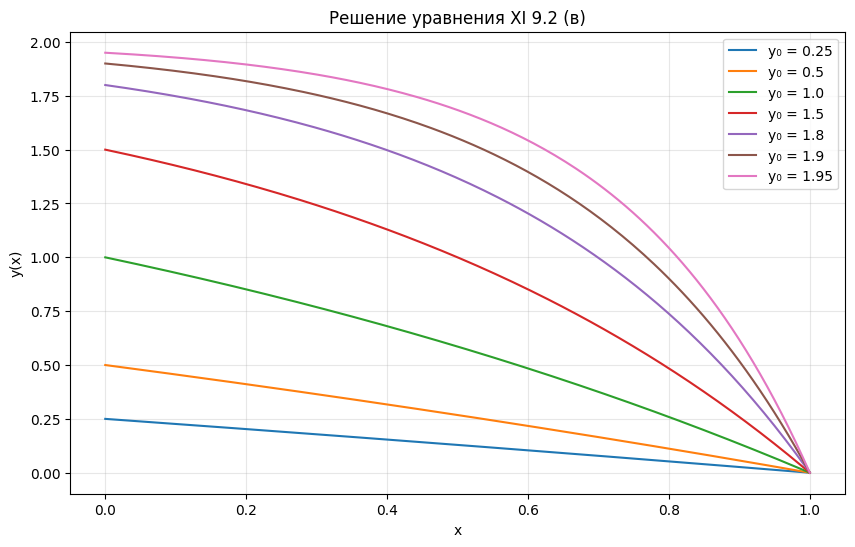

In [2]:
y0_values = [0.25, 0.5, 1.0, 1.5, 1.8, 1.9, 1.95]

def XI_92(x, y, yp):
    denominator = 1 - 0.5 * y
    return -0.5 / denominator * yp**2

plt.figure(figsize=(10, 6))

for y0 in y0_values:
    print(f"Решаем для y0 = {y0}")
    
    problem = SecondOrderEquation(
        f=XI_92,
        alpha=y0,   # y(0) = y0
        beta=0,     # y(1) = 0
        domain=(0, 1)
    )
    
    solver = QuasilinearizationSolver(problem, n_points=200)
    
    x, y = solver.solve(tol=1e-8, max_iter=50, verbose=False)
    
    plt.plot(x, y, label=f"y₀ = {y0}")

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Решение уравнения XI 9.2 (в)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Решение той же задачи методом стрельбы

Решаем для y0 =  0.25
Решаем для y0 =  0.5
Решаем для y0 =  1.0
Решаем для y0 =  1.5
Решаем для y0 =  1.8
Решаем для y0 =  1.9
Решаем для y0 =  1.95


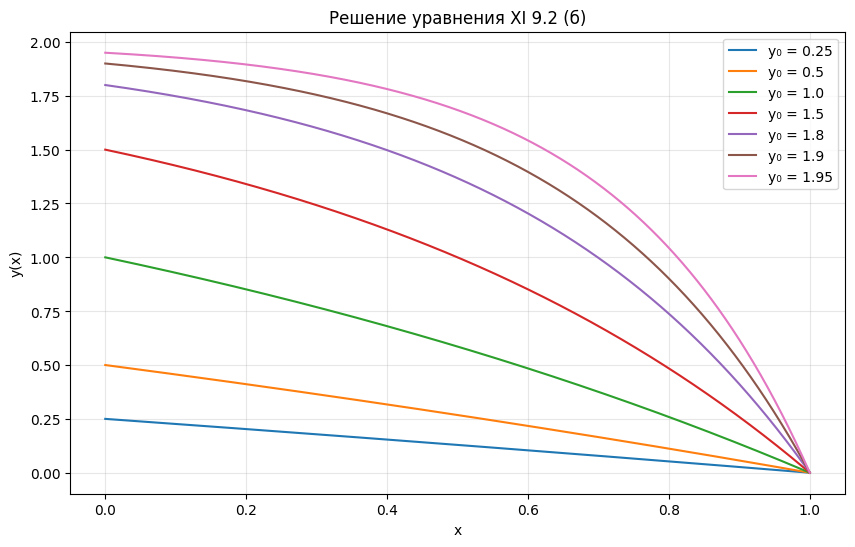

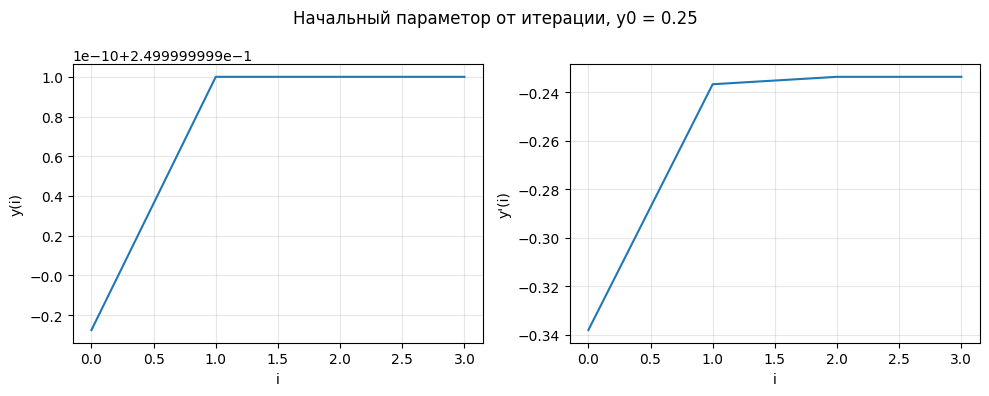

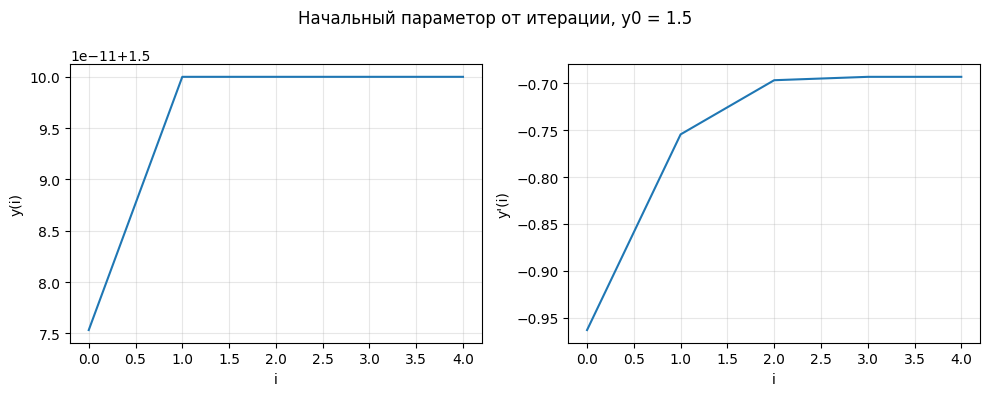

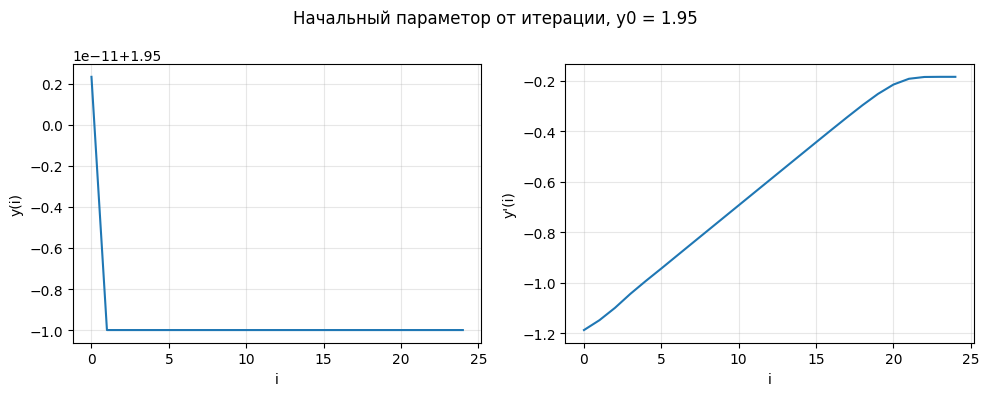

In [3]:
# def system3(x, y):
#     return np.array([y[1], -y[0]])

def system_XI_92(x, y):

    return np.array([y[1], -0.5 / (1.0 - 0.5 * y[0]) * (y[1] ** 2)])

# одно начальное приближение для всех y0
a0 = [1.8, -0.1]

plt.figure(figsize=(10, 6))

# для графиков alpha(iter)
iters = []
alphas = []
yalphas = []

for y0 in y0_values:
    print("Решаем для y0 = ", y0)
    # def bc3(ya, yb):
        # y'(0) + 2y(0) = 3
        # y(1) = y0
        # return np.array([ya[1] + 2*ya[0] - 3, yb[0] - y0])
    
    def bc_XI_92(ya, yb):
        return np.array([ya[0] - y0, yb[0]])

    # problem3 = FirstOrderSystem(system3, bc3, domain=(0, np.pi / 2))
    problem3 = FirstOrderSystem(system_XI_92, bc_XI_92, domain=(0, 1))
    solver3 = ShootingSolver(problem3)
    x3, y3 = solver3.solve(a0, max_iter=50)

  
    iter, alpha = solver3.get_alphas()

    iters.append(iter)
    alphas.append(alpha)
    yalphas.append(y0)

    plt.plot(x3, list(map(lambda yn: yn[0], y3)), label=f"y₀ = {y0}")

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Решение уравнения XI 9.2 (б)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

def make_alpha_graphs(i_list: list[float] = range(0, len(iters))):
    for i in i_list:
        fig, axes = plt.subplots(1, 2, figsize=[10, 4])
        fig.suptitle("Начальный параметор от итерации, y0 = " + str(yalphas[i]))

        plt.subplot(1, 2, 1)
        plt.plot(iters[i], list(map(lambda an: an[0], alphas[i])))
        plt.grid(True, alpha=0.3)
        axes[0].set_xlabel("i")
        axes[0].set_ylabel("y(i)")

        plt.subplot(1, 2, 2)
        plt.plot(iters[i], list(map(lambda an: an[1], alphas[i])))
        axes[1].set_xlabel("i")
        axes[1].set_ylabel("y'(i)")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()

# не перегружаем вывод
make_alpha_graphs([0, 3, 6])


### Нахождение собственныз значений

Поиск периодических решений для потенциала Тоды
Уравнение: x'' = 1 - e^x
Граничные условия: x(0)=x(120)=0, x'(0)=x'(120)=A, A >= 10

Исследование зависимости x(120) от A:
         A |          x(120) |          v(120) |        v(120)-A
------------------------------------------------------------
   10.0000 |   -4.758960e+01 |    2.611664e+00 |   -7.388336e+00
   12.1053 |   -5.825867e+01 |    5.658626e+00 |   -6.446637e+00
   14.2105 |   -2.107204e+01 |   -1.271987e+01 |   -2.693039e+01
   16.3158 |   -1.314539e+02 |    2.301565e+00 |   -1.401422e+01
   18.4211 |   -9.692851e+01 |   -1.214406e+01 |   -3.056511e+01
   20.5263 |   -9.668202e+01 |    1.516462e+01 |   -5.361699e+00
   22.6316 |   -2.456189e+02 |    4.790683e+00 |   -1.784090e+01
   24.7368 |   -2.912485e+02 |   -5.604851e+00 |   -3.034169e+01
   26.8421 |   -2.329682e+02 |   -1.601756e+01 |   -4.285967e+01
   28.9474 |   -7.032803e+01 |   -2.644417e+01 |   -5.539154e+01
   31.0526 |   -1.509967e+02 |    2.577349e+01 |   -5

/var/folders/yp/8m035mj14pb8sd9thkrj0v_m0000gn/T/ipykernel_2706/1381384888.py:9: RuntimeWarning: overflow encountered in exp
  return np.array([y[1], 1 - np.exp(y[0])])
/Users/stepan/Study/mipt/5sem/comp_math/comp_math_project/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/rk.py:63: RuntimeWarning: overflow encountered in multiply
  dy = np.dot(K[:s].T, a[:s]) * h
/Users/stepan/Study/mipt/5sem/comp_math/comp_math_project/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/rk.py:109: RuntimeWarning: overflow encountered in divide
  return norm(self._estimate_error(K, h) / scale)


   41.5789 |   -8.497711e+02 |   -5.591661e+00 |   -4.717061e+01
   43.6842 |   -8.846429e+02 |   -1.187537e+01 |   -5.555959e+01
   45.7895 |   -8.844156e+02 |   -1.816163e+01 |   -6.395110e+01
   47.8947 |   -8.490489e+02 |   -2.445011e+01 |   -7.234485e+01
   50.0000 |   -7.785082e+02 |   -3.074058e+01 |   -8.074058e+01
Вычисление невязок для различных A...


/Users/stepan/Study/mipt/5sem/comp_math/comp_math_project/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/rk.py:66: RuntimeWarning: overflow encountered in multiply
  y_new = y + h * np.dot(K[:-1].T, B)



Найдено 0 периодических решений с A >= 10:


/var/folders/yp/8m035mj14pb8sd9thkrj0v_m0000gn/T/ipykernel_2706/1381384888.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='best', fontsize=8)
/var/folders/yp/8m035mj14pb8sd9thkrj0v_m0000gn/T/ipykernel_2706/1381384888.py:172: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(loc='best', fontsize=8)
/var/folders/yp/8m035mj14pb8sd9thkrj0v_m0000gn/T/ipykernel_2706/1381384888.py:182: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend(loc='best', fontsize=8)


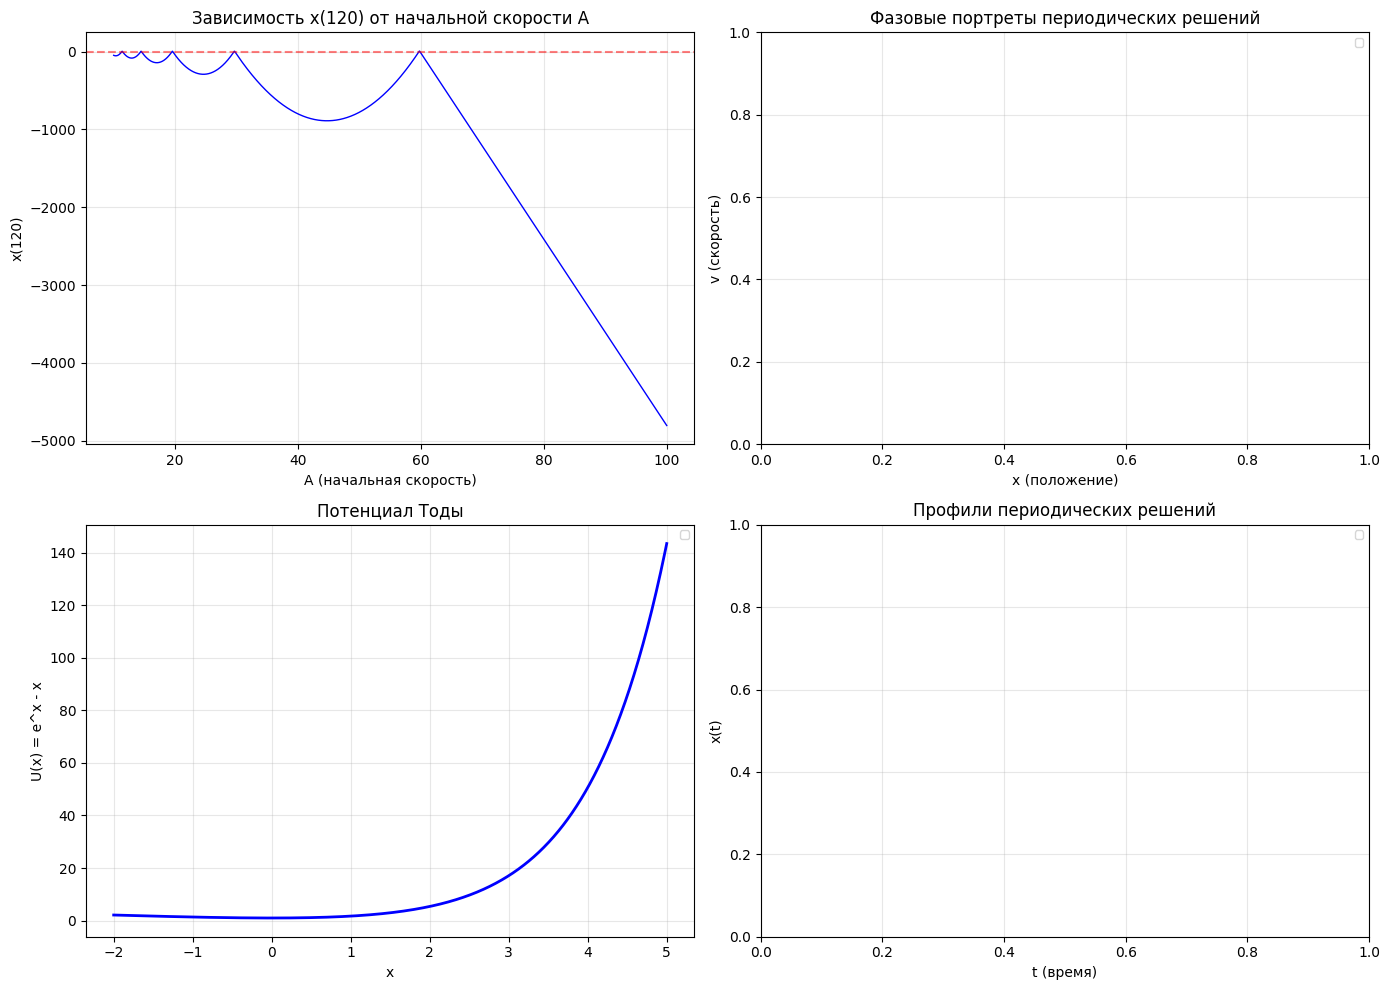


ДЕТАЛЬНЫЙ АНАЛИЗ НАЙДЕННЫХ РЕШЕНИЙ

Результаты сохранены в файл 'toda_solutions.txt'
Графики сохранены в файл 'toda_periodic_solutions.png'


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, bisect
from comp_math.bvp.model.first_order_system import FirstOrderSystem

# Определяем систему первого порядка
def toda_system(x, y):
    """y = [x, v] где v = dx/dt"""
    return np.array([y[1], 1 - np.exp(y[0])])

# Краевые условия для периодического решения
def periodic_bc(ya, yb):
    """ya и yb - векторы [x(a), v(a)] и [x(b), v(b)]"""
    return np.array([ya[0] - 0,      # x(0) = 0
                     yb[0] - 0,      # x(120) = 0
                     ya[1] - yb[1]]) # v(0) = v(120)

# Преобразуем краевые условия в формат FirstOrderSystem
# Нам нужно 3 условия: x(0)=0, x(120)=0, v(0)-v(120)=0
# Но стандартный bc ожидает 2 условия? Нет, он ожидает n условий для n переменных
# У нас 2 переменные, нужно 2 условия

# Переформулируем задачу: 
# У нас есть параметр A - начальная скорость
# Нужно найти A такое, что x(120) = 0 при x(0)=0, v(0)=A
# И дополнительно v(120) = A (периодичность)

# Создадим функцию, которая для заданного A решает задачу Коши
def solve_for_A(A, t_span=(0, 120), t_eval=None):
    """Решает задачу Коши для заданного A и возвращает x(120) и v(120)"""
    y0 = [0, A]  # x(0)=0, v(0)=A
    
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 1000)
    
    from scipy.integrate import solve_ivp
    sol = solve_ivp(toda_system, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
    
    x_final = sol.y[0, -1]
    v_final = sol.y[1, -1]
    
    return sol.t, sol.y[0], sol.y[1], x_final, v_final

# Функция невязки для поиска A
def residual(A):
    """Невязка: x(120) должно быть 0, и v(120) должно равняться A"""
    _, _, _, x_final, v_final = solve_for_A(A)
    # Возвращаем x(120) (периодичность по положению)
    return x_final

def residual_with_periodicity(A):
    """Невязка с учетом периодичности скорости"""
    _, _, _, x_final, v_final = solve_for_A(A)
    # Должны выполняться оба условия
    return np.array([x_final, v_final - A])

# Поиск всех A >= 10, для которых x(120)=0
def find_all_periodic_solutions(A_min=10, A_max=50, n_points=1000):
    """Находит все A >= A_min, для которых существуют периодические решения"""
    
    A_vals = np.linspace(A_min, A_max, n_points)
    residuals = []
    
    print("Вычисление невязок для различных A...")
    for A in A_vals:
        res = residual(A)
        residuals.append(res)
    
    residuals = np.array(residuals)
    
    # Находим пересечения с нулем
    solutions = []
    for i in range(len(A_vals) - 1):
        if residuals[i] * residuals[i+1] <= 0:
            # Нашли интервал, где есть корень
            try:
                root = root_scalar(residual, bracket=[A_vals[i], A_vals[i+1]], 
                                 method='secant', xtol=1e-10)
                if root.converged:
                    solutions.append(root.root)
            except:
                pass
    
    # Убираем дубликаты
    solutions = np.unique(np.round(solutions, decimals=8))
    
    # Проверяем периодичность скорости для найденных решений
    periodic_solutions = []
    for A in solutions:
        _, _, _, x_final, v_final = solve_for_A(A)
        if abs(x_final) < 1e-8 and abs(v_final - A) < 1e-6:
            periodic_solutions.append(A)
    
    return periodic_solutions, A_vals, residuals

# Поиск решений
print("=" * 60)
print("Поиск периодических решений для потенциала Тоды")
print("Уравнение: x'' = 1 - e^x")
print("Граничные условия: x(0)=x(120)=0, x'(0)=x'(120)=A, A >= 10")
print("=" * 60)

# Сначала исследуем поведение
A_test = np.linspace(10, 50, 20)
print("\nИсследование зависимости x(120) от A:")
print(f"{'A':>10} | {'x(120)':>15} | {'v(120)':>15} | {'v(120)-A':>15}")
print("-" * 60)

for A in A_test:
    _, _, _, x_final, v_final = solve_for_A(A)
    print(f"{A:10.4f} | {x_final:15.6e} | {v_final:15.6e} | {v_final - A:15.6e}")

# Находим все периодические решения
solutions, A_vals, residuals = find_all_periodic_solutions(A_min=10, A_max=100, n_points=2000)

print("\n" + "=" * 60)
print(f"Найдено {len(solutions)} периодических решений с A >= 10:")
print("=" * 60)

for i, A in enumerate(solutions):
    print(f"\nРешение {i+1}: A = {A:.10f}")
    t, x, v, x_final, v_final = solve_for_A(A)
    print(f"  x(120) = {x_final:.2e}")
    print(f"  v(120) = {v_final:.10f}")
    print(f"  Период = 120")
    print(f"  Энергия = {np.exp(x[0]) - x[0]:.6f}")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Зависимость x(120) от A
ax1 = axes[0, 0]
ax1.plot(A_vals, residuals, 'b-', linewidth=1)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
for A in solutions:
    ax1.axvline(x=A, color='g', linestyle='--', alpha=0.7)
    ax1.plot(A, 0, 'go', markersize=8)
ax1.set_xlabel('A (начальная скорость)')
ax1.set_ylabel('x(120)')
ax1.set_title('Зависимость x(120) от начальной скорости A')
ax1.grid(True, alpha=0.3)

# График 2: Фазовые портреты найденных решений
ax2 = axes[0, 1]
colors = plt.cm.viridis(np.linspace(0, 1, len(solutions)))
for i, A in enumerate(solutions[:min(5, len(solutions))]):  # Показываем не более 5 решений
    t, x, v, _, _ = solve_for_A(A)
    ax2.plot(x, v, color=colors[i], linewidth=1.5, label=f'A = {A:.4f}')
ax2.set_xlabel('x (положение)')
ax2.set_ylabel('v (скорость)')
ax2.set_title('Фазовые портреты периодических решений')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# График 3: Зависимость периода от A (теоретическая)
ax3 = axes[1, 0]
# Для периодических решений в потенциале Тоды
x_range = np.linspace(-2, 5, 1000)
U = np.exp(x_range) - x_range
ax3.plot(x_range, U, 'b-', linewidth=2)
ax3.set_xlabel('x')
ax3.set_ylabel('U(x) = e^x - x')
ax3.set_title('Потенциал Тоды')
ax3.grid(True, alpha=0.3)

# Отметим уровни энергии найденных решений
for i, A in enumerate(solutions):
    t, x, v, _, _ = solve_for_A(A)
    E = np.exp(x[0]) - x[0] + v[0]**2/2
    ax3.axhline(y=E, color=colors[i] if i < len(colors) else 'r', 
                linestyle='--', alpha=0.5, label=f'E = {E:.4f}')
ax3.legend(loc='best', fontsize=8)

# График 4: Профили x(t) для найденных решений
ax4 = axes[1, 1]
for i, A in enumerate(solutions[:min(5, len(solutions))]):
    t, x, v, _, _ = solve_for_A(A)
    ax4.plot(t, x, color=colors[i], linewidth=1.5, label=f'A = {A:.4f}')
ax4.set_xlabel('t (время)')
ax4.set_ylabel('x(t)')
ax4.set_title('Профили периодических решений')
ax4.legend(loc='best', fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('toda_periodic_solutions.png', dpi=150, bbox_inches='tight')
plt.show()

# Детальный анализ каждого найденного решения
print("\n" + "=" * 60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ НАЙДЕННЫХ РЕШЕНИЙ")
print("=" * 60)

for i, A in enumerate(solutions):
    print(f"\n--- Решение {i+1} ---")
    print(f"Начальная скорость A = {A:.12f}")
    
    t, x, v, x_final, v_final = solve_for_A(A)
    
    print(f"Проверка граничных условий:")
    print(f"  x(0) = 0 (задано)")
    print(f"  x(120) = {x_final:.2e} (должно быть 0)")
    print(f"  v(0) = {A:.12f}")
    print(f"  v(120) = {v_final:.12f}")
    print(f"  Разность v(120)-v(0) = {v_final - A:.2e}")
    
    # Энергия
    E = np.exp(x[0]) - x[0] + v[0]**2/2
    print(f"Полная энергия: E = {E:.10f}")
    
    # Амплитуда
    x_max = np.max(x)
    x_min = np.min(x)
    print(f"Амплитуда: x_max = {x_max:.6f}, x_min = {x_min:.6f}")
    
    # Период (должен быть 120)
    # Найдем момент, когда x возвращается к 0 с положительной скоростью
    zero_crossings = np.where(np.diff(np.sign(x)) > 0)[0]
    if len(zero_crossings) > 1:
        T_computed = t[zero_crossings[1]] - t[zero_crossings[0]]
        print(f"Вычисленный период: {T_computed:.6f} (теоретический: 120)")

# Сохраняем результаты
np.savetxt('toda_solutions.txt', 
           np.column_stack([range(1, len(solutions)+1), solutions]),
           header='Номер_решения    Значение_A',
           fmt='%d %.12f')

print("\n" + "=" * 60)
print("Результаты сохранены в файл 'toda_solutions.txt'")
print("Графики сохранены в файл 'toda_periodic_solutions.png'")
print("=" * 60)


[1] Грубый поиск: вычисление x(T) для различных A...
  Прогресс: 500/3000 (17%)
  Прогресс: 1000/3000 (33%)
  Прогресс: 1500/3000 (50%)
  Прогресс: 2000/3000 (67%)
  Прогресс: 2500/3000 (83%)
  Прогресс: 3000/3000 (100%)


/var/folders/yp/8m035mj14pb8sd9thkrj0v_m0000gn/T/ipykernel_4133/443020515.py:10: RuntimeWarning: overflow encountered in exp
  return np.array([y[1], 1 - np.exp(y[0])])


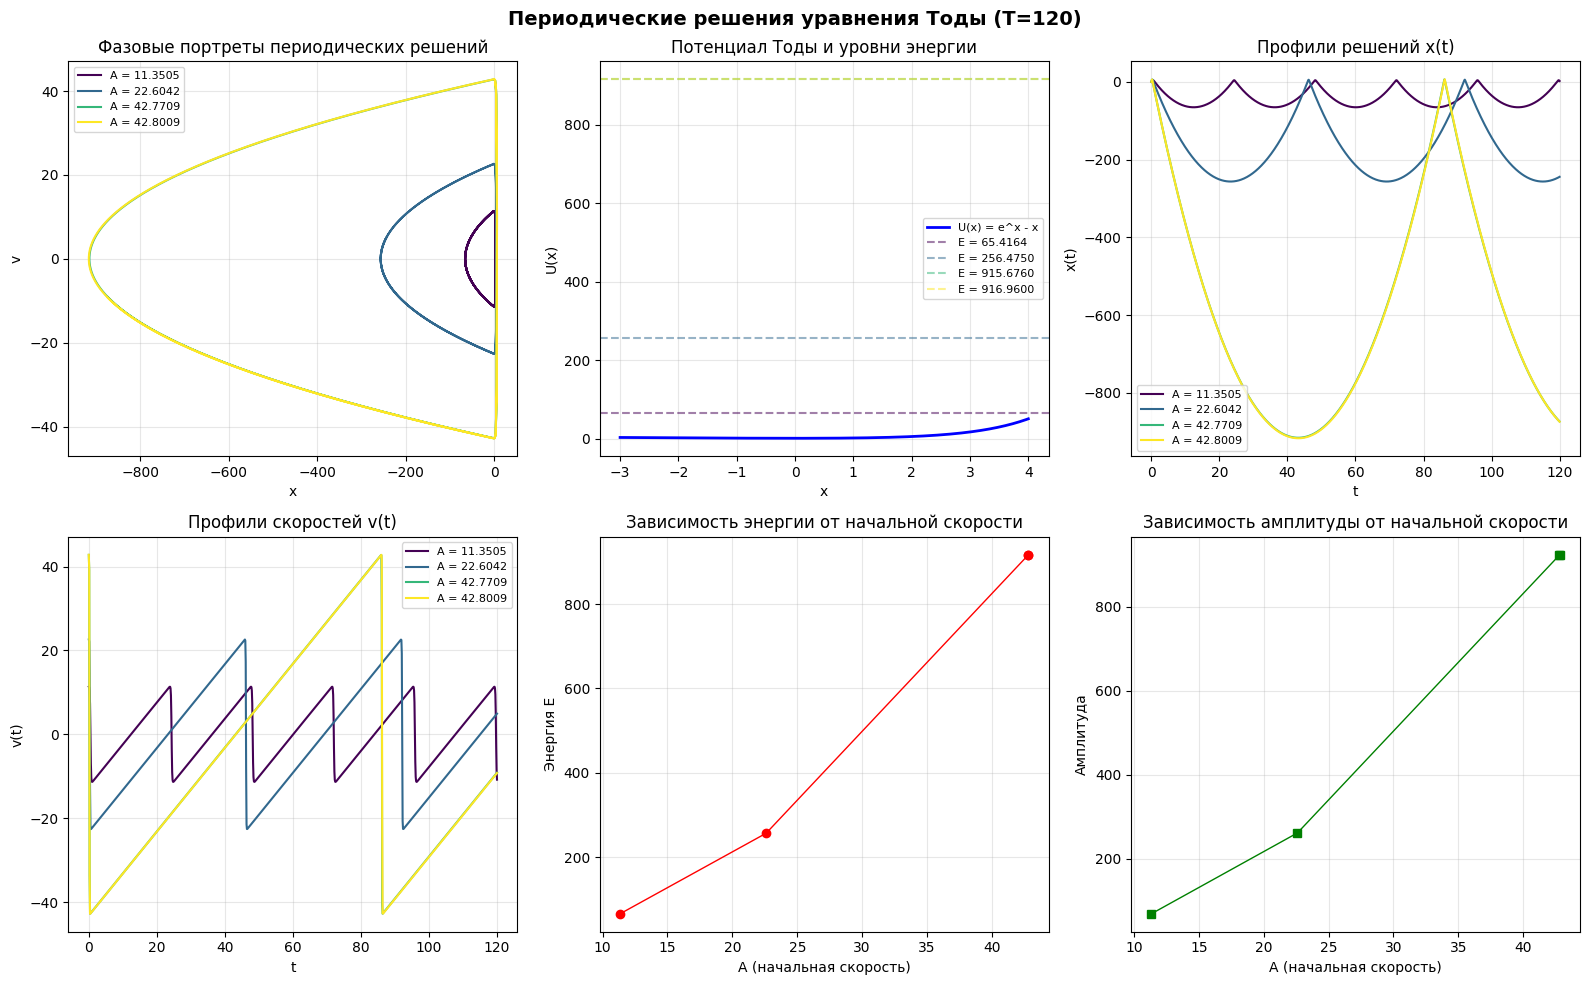

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from comp_math.bvp.model.first_order_system import FirstOrderSystem
from comp_math.ode.ode_registry import ODERegistry


def toda_system(x, y):
    """Система для потенциала Тоды: y = [x, v]"""
    return np.array([y[1], 1 - np.exp(y[0])])

def toda_system_new(x, y):
    return Vector(toda_system(x, y))

class TodaPeriodicSolver:    
    def __init__(self, T=120, tol=2):
        self.T = T
        self.tol = tol
        self.solutions = []
        self.solver = None
        
    def create_bvp_problem(self, A):
        """Создает краевую задачу для заданного A"""
        def system(x, y):
            return toda_system(x, y)
        
        def bc(ya, yb):
            return np.array([ya[0], yb[0]])
        
        return FirstOrderSystem(system, bc, domain=(0, self.T))
    
    def solve_for_A(self, A, h=0.01, max_iter=50):
        """Решает краевую задачу для заданного A с помощью ShootingSolver"""
        try:
            
            problem = self.create_bvp_problem(A)
            solver = ShootingSolver(problem, ode_solver_name="rk4", sla_solver_name="bcg")
            
            # Начальное приближение
            a0 = np.array([0, A])
            
            t, y = solver.solve(a0, h=h, tol=self.tol, max_iter=max_iter, record_alpha=False)
            
            x_final = y[-1][0]
            v_final = y[-1][1]
            v_periodicity = abs(v_final - A)
            
            if abs(x_final) < self.tol and v_periodicity < self.tol:
                return t, y, True
            else:
                return t, y, False
                
        except Exception as e:
            return None, None, False
    
    def find_periodic_solutions(self, A_min=10, A_max=100, n_search=1000, h=0.01):
        """Находит все периодические решения в заданном диапазоне A"""
        
        A_vals = np.linspace(A_min, A_max, n_search)
        x_finals = []
        
        print("Вычисление x(T) для различных A...")
        
        for i, A in enumerate(A_vals):            
            solver = ODERegistry.create_solver("euler")
            t, y = solver.solve(toda_system_new, 1, (0, self.T), [0, A], 0.01)
            x_finals.append(y[-1][0])
            
            if (i + 1) % 500 == 0:
                print(f"  Прогресс: {i+1}/{n_search} ({100*(i+1)/n_search:.0f}%)")
        
        x_finals = np.array(x_finals)
        
        # Поиск корней x(T)=0        
        solutions = []
        roots_info = []
        
        for i in range(len(A_vals) - 1):
            if x_finals[i] * x_finals[i+1] <= 0 and x_finals[i] != x_finals[i+1]:
                # Нашли интервал, содержащий корень
                try:
                    # Определяем функцию невязки
                    def residual(A):
                        problem = self.create_bvp_problem(A)
                        solver = ShootingSolver(problem, ode_solver_name="rk4", 
                                               sla_solver_name="bcg")
                        a0 = np.array([0, A])
                        try:
                            t, y = solver.solve(a0, h=h, tol=1e-8, 
                                               max_iter=30, record_alpha=False)
                            return y[-1][0]
                        except:
                            return np.nan
                    
                    # Уточняем корень
                    result = root_scalar(residual, bracket=[A_vals[i], A_vals[i+1]], 
                                        method='brentq', xtol=self.tol, rtol=self.tol)
                    
                    if result.converged:
                        A_root = result.root
                        
                        t, y, success = self.solve_for_A(A_root, h=h)
                        
                        solutions.append(A_root)
                                
                except Exception as e:
                    continue
        
        self.solutions = solutions
        self.roots_info = roots_info
        
        return solutions, roots_info
                
    def visualize(self):
        """Визуализация найденных решений"""
        if not self.solutions:
            print("Нет решений для визуализации.")
            return
        
        n_solutions = min(5, len(self.solutions))
        colors = plt.cm.viridis(np.linspace(0, 1, n_solutions))
        
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        
        # 1. Фазовые портреты
        ax1 = axes[0, 0]
        for i, A in enumerate(self.solutions[:n_solutions]):
            if i < len(self.roots_info) and self.roots_info[i] is not None:
                t = self.roots_info[i]['t']
                y = self.roots_info[i]['y']
                x = np.array([yi[0] for yi in y])
                v = np.array([yi[1] for yi in y])
                ax1.plot(x, v, color=colors[i], linewidth=1.5, label=f'A = {A:.4f}')
            else:
                from scipy.integrate import solve_ivp
                sol = solve_ivp(toda_system, (0, self.T), [0, A], 
                               method='DOP853', rtol=1e-10, atol=1e-12,
                               t_eval=np.linspace(0, self.T, 2000))
                ax1.plot(sol.y[0], sol.y[1], color=colors[i], linewidth=1.5, 
                        label=f'A = {A:.4f}')
        ax1.set_xlabel('x')
        ax1.set_ylabel('v')
        ax1.set_title('Фазовые портреты периодических решений')
        ax1.legend(loc='best', fontsize=8)
        ax1.grid(True, alpha=0.3)
        
        # 2. Потенциал Тоды с уровнями энергии
        ax2 = axes[0, 1]
        x_range = np.linspace(-3, 4, 1000)
        U = np.exp(x_range) - x_range
        ax2.plot(x_range, U, 'b-', linewidth=2, label='U(x) = e^x - x')
        
        for i, A in enumerate(self.solutions[:n_solutions]):
            if i < len(self.roots_info) and self.roots_info[i] is not None:
                y = self.roots_info[i]['y']
                x0 = y[0][0]
                v0 = y[0][1]
            else:
                from scipy.integrate import solve_ivp
                sol = solve_ivp(toda_system, (0, self.T), [0, A], 
                               method='DOP853', rtol=1e-10, atol=1e-12)
                x0, v0 = sol.y[0, 0], sol.y[1, 0]
            
            E = np.exp(x0) - x0 + v0**2/2
            ax2.axhline(y=E, color=colors[i], linestyle='--', alpha=0.5, 
                       label=f'E = {E:.4f}')
        
        ax2.set_xlabel('x')
        ax2.set_ylabel('U(x)')
        ax2.set_title('Потенциал Тоды и уровни энергии')
        ax2.legend(loc='best', fontsize=8)
        ax2.grid(True, alpha=0.3)
        
        # 3. Профили x(t)
        ax3 = axes[0, 2]
        for i, A in enumerate(self.solutions[:n_solutions]):
            if i < len(self.roots_info) and self.roots_info[i] is not None:
                t = self.roots_info[i]['t']
                y = self.roots_info[i]['y']
                x = np.array([yi[0] for yi in y])
                ax3.plot(t, x, color=colors[i], linewidth=1.5, label=f'A = {A:.4f}')
            else:
                from scipy.integrate import solve_ivp
                t_eval = np.linspace(0, self.T, 1000)
                sol = solve_ivp(toda_system, (0, self.T), [0, A], 
                               t_eval=t_eval, method='DOP853', 
                               rtol=1e-10, atol=1e-12)
                ax3.plot(sol.t, sol.y[0], color=colors[i], linewidth=1.5, 
                        label=f'A = {A:.4f}')
        ax3.set_xlabel('t')
        ax3.set_ylabel('x(t)')
        ax3.set_title('Профили решений x(t)')
        ax3.legend(loc='best', fontsize=8)
        ax3.grid(True, alpha=0.3)
        
        # 4. Профили v(t)
        ax4 = axes[1, 0]
        for i, A in enumerate(self.solutions[:n_solutions]):
            if i < len(self.roots_info) and self.roots_info[i] is not None:
                t = self.roots_info[i]['t']
                y = self.roots_info[i]['y']
                v = np.array([yi[1] for yi in y])
                ax4.plot(t, v, color=colors[i], linewidth=1.5, label=f'A = {A:.4f}')
            else:
                from scipy.integrate import solve_ivp
                t_eval = np.linspace(0, self.T, 1000)
                sol = solve_ivp(toda_system, (0, self.T), [0, A], 
                               t_eval=t_eval, method='DOP853', 
                               rtol=1e-10, atol=1e-12)
                ax4.plot(sol.t, sol.y[1], color=colors[i], linewidth=1.5, 
                        label=f'A = {A:.4f}')
        ax4.set_xlabel('t')
        ax4.set_ylabel('v(t)')
        ax4.set_title('Профили скоростей v(t)')
        ax4.legend(loc='best', fontsize=8)
        ax4.grid(True, alpha=0.3)
        
        # 5. Энергия vs A
        ax5 = axes[1, 1]
        energies = []
        for A in self.solutions:
            from scipy.integrate import solve_ivp
            sol = solve_ivp(toda_system, (0, self.T), [0, A], 
                           method='DOP853', rtol=1e-10, atol=1e-12)
            E = np.exp(sol.y[0, 0]) - sol.y[0, 0] + sol.y[1, 0]**2/2
            energies.append(E)
        
        ax5.plot(self.solutions, energies, 'ro-', markersize=6, linewidth=1)
        ax5.set_xlabel('A (начальная скорость)')
        ax5.set_ylabel('Энергия E')
        ax5.set_title('Зависимость энергии от начальной скорости')
        ax5.grid(True, alpha=0.3)
        
        # 6. Амплитуда vs A
        ax6 = axes[1, 2]
        amplitudes = []
        for A in self.solutions:
            from scipy.integrate import solve_ivp
            t_eval = np.linspace(0, self.T, 10000)
            sol = solve_ivp(toda_system, (0, self.T), [0, A], 
                           t_eval=t_eval, method='DOP853', 
                           rtol=1e-10, atol=1e-12)
            amplitude = np.max(sol.y[0]) - np.min(sol.y[0])
            amplitudes.append(amplitude)
        
        ax6.plot(self.solutions, amplitudes, 'gs-', markersize=6, linewidth=1)
        ax6.set_xlabel('A (начальная скорость)')
        ax6.set_ylabel('Амплитуда')
        ax6.set_title('Зависимость амплитуды от начальной скорости')
        ax6.grid(True, alpha=0.3)
        
        plt.suptitle(f'Периодические решения уравнения Тоды (T={self.T})', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

solver = TodaPeriodicSolver(T=120, tol=2)

solutions, roots_info = solver.find_periodic_solutions(
    A_min=10, 
    A_max=100, 
    n_search=3000,
    h=0.01
)

solver.visualize()